In [47]:
import numpy as np
import pandas as pd
import odl
import math
import matplotlib.pyplot as plt
import sys
sys.path.append("../..")
from pathlib import Path

In [48]:
from src.transforms import nodal_image_to_dg
from src.evaluation import eval_dg_on_img_grid
from src.siac_modal import apply_siac_modal_dg_2d
from src.siac_fourier import apply_siac_fft_nd
from src.utils import _to_numpy

from src.tomo import(
    make_space_2d, 
    shepp_logan_2d, 
    parallel_geom_2d, 
    ray_transform_2d, 
    reconstruct_fbp, 
    add_relative_gaussian_noise, 
    multi_disk_phantom_2d, 
)

from src.metrics import(
    rel_l2_err, 
    ssim, 
    gradient_weighted_ssim, 
    eval_metrics, 
    build_metrics_table
)

from src.plotting_helpers import (
    plot_img, 
    plot_img_zoom, 
    save_image_w_zoom, 
    plot_param_heatmap_single_run
)


In [49]:
### Create the reconstruction space and phantom ###

xmin, xmax, ymin, ymax = -20, 20, -20, 20
Nx, Ny = 128, 128

space = make_space_2d(Nx=Nx, Ny=Ny, domain=[xmin, xmax, ymin, ymax])

# Need to change: mask_keep_largest argument for build_metrics_table to False unless using Shepp Logan, then True
phantom = shepp_logan_2d(space)
# phantom = multi_disk_phantom_2d(space)

# phantom_name = "multi_disc"
phantom_name = "shepp_logan"

phantom_np = phantom.asarray()

# Full angular coverage (mimic CT)
angular_coverage=(-90,90)
step = 3                    # angular resolution (3 degrees per step)

# detector half-width should be at least the half-diagonal of the reconstruction box
r = np.sqrt((0.5*(xmax - xmin))**2 + (0.5*(ymax - ymin))**2)
det_range = (-r, r)

det_count = int(np.ceil(1.5 * np.sqrt(Nx**2 + Ny**2)))

geom = parallel_geom_2d(angular_coverage=angular_coverage, step=step, 
                        det_range=det_range, det_count=det_count)
A = ray_transform_2d(space, geom)
data_space = A.range

sinogram = A(phantom)

# testing with 10% Noise here
sino_noisy = add_relative_gaussian_noise(sinogram, rel_level=0.1)


In [50]:
# ------------------------------------------------------------
# Helper
# ------------------------------------------------------------

def save_pointwise_error_image(E, save_path, vmin, vmax,
                               figsize=(5, 5), dpi=300,
                               cmap="seismic",
                               add_colorbar=False):
    """
    Save signed pointwise error image with fixed color scale.
    """
    E = _to_numpy(E)

    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(E, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.axis("off")

    if add_colorbar:
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.savefig(save_path, dpi=dpi, bbox_inches="tight", pad_inches=0)
    plt.close(fig)

    return str(save_path)

In [51]:
# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
xmin, ymin = space.min_pt
xmax, ymax = space.max_pt

xlim = (xmin, xmax)
ylim = (ymin, ymax)

fig_dir = Path("figures")

results = []

phantom_np = _to_numpy(phantom)

# Central horizontal slice index
slice_idx = phantom_np.shape[0] // 2

# Physical x-axis
x = np.linspace(xlim[0], xlim[1], phantom_np.shape[1])

In [52]:
# ------------------------------------------------------------
# Baseline FBP reconstructions
# ------------------------------------------------------------

fbp_ramp = reconstruct_fbp(sino_noisy, A, filter_name="Ram-Lak")
fbp_ramp_np = _to_numpy(fbp_ramp)

results.append({
    "method": "Ram--Lak",
    "U": fbp_ramp_np,
    "label": "Ram--Lak",
    "save_name": f"{phantom_name}_fbp_ram_lak_pointwise_err.pdf",
    "params": {}
})


fbp_hann = reconstruct_fbp(sino_noisy, A, filter_name="Hann")
fbp_hann_np = _to_numpy(fbp_hann) 

results.append({
    "method": "Hann",
    "U": fbp_hann_np,
    "label": "Hann",
    "save_name": f"{phantom_name}_fbp_hann_pointwise_err.pdf",
    "params": {}
})

In [53]:
# ------------------------------------------------------------
# Nodal-to-Modal SIAC configurations
# ------------------------------------------------------------

config_NM = [
    {"p": 1, "r+1": 5, "n": 1, "label": r"SIAC $p=1,\ r+1=5,\ n=1$", "color": "tab:blue"},
    {"p": 1, "r+1": 3, "n": 2, "label": r"SIAC $p=1,\ r+1=3,\ n=2$", "color": "tab:red"},
    {"p": 3, "r+1": 7, "n": 4, "label": r"SIAC $p=3,\ r+1=7,\ n=4$", "color": "tab:cyan"},
]

# Base reconstruction for nodal-to-modal SIAC.
# Usually this should be Ram-Lak if SIAC is used as postprocessing after FBP inversion.
base_recon_NM = fbp_ramp

for cfg in config_NM:
    p = cfg["p"]
    rp1 = cfg["r+1"]
    n = cfg["n"]

    # implementation uses moments = r = (r+1)-1
    moments = rp1 - 1
    BSorder = n

    dg = nodal_image_to_dg(
        recon=base_recon_NM,
        xlim=xlim,
        ylim=ylim,
        p=p
    )

    Ustar = apply_siac_modal_dg_2d(
        dg=dg,
        moments=moments,
        BSorder=BSorder
    )

    Ustar_np = _to_numpy(Ustar)

    results.append({
        "method": "Nodal-to-Modal SIAC",
        "U": Ustar_np,
        "label": cfg["label"],
        "save_name": f"{phantom_name}_siac_dg_p{p}r{rp1}n{n}_pointwise_err.pdf",
        "params": {
            "p": p,
            "r+1": rp1,
            "r": moments,
            "n": n
        }
    })

In [54]:
# ------------------------------------------------------------
# Fourier SIAC postprocessor
# ------------------------------------------------------------

dx, dy = space.cell_sides
d_ang, d_det = data_space.cell_sides

rp1_fourier = 3
r_fourier = rp1_fourier - 1
n_fourier = 10

fbp_fourier_siac = apply_siac_fft_nd(
    arr=fbp_ramp_np,
    h_per_axis=(dy, dx),
    axes=(0, 1),
    moments=r_fourier,
    BSorder=n_fourier,
    pad_mode="reflect"
)

fbp_fourier_siac_np = _to_numpy(fbp_fourier_siac)

results.append({
    "method": "Fourier SIAC",
    "U": fbp_fourier_siac_np,
    "label": rf"Fourier SIAC $r+1={rp1_fourier},\ n={n_fourier}$",
    "save_name": f"{phantom_name}_fourier_siac_r{rp1_fourier}n{n_fourier}_pointwise_err.pdf",
    "params": {
        "r+1": rp1_fourier,
        "r": r_fourier,
        "n": n_fourier
    }
})

In [55]:
# ------------------------------------------------------------
# Detector-domain SIAC
# ------------------------------------------------------------

rp1_det = 5
r_det = rp1_det - 1
n_det = 25

sino_noisy_np = _to_numpy(sino_noisy)

sino_np_siac = apply_siac_fft_nd(
    arr=sino_noisy_np,
    h_per_axis=d_det,
    axes=(1,),
    moments=r_det,
    BSorder=n_det,
    pad_mode="reflect"
)

sino_odl_siac = data_space.element(sino_np_siac)

fbp_detector_siac_odl = reconstruct_fbp(
    sino_odl_siac,
    A,
    filter_name="Ram-Lak"
)

fbp_detector_siac_np = _to_numpy(fbp_detector_siac_odl)

results.append({
    "method": "Detector SIAC",
    "U": fbp_detector_siac_np,
    "label": rf"Detector SIAC $r+1={rp1_det},\ n={n_det}$",
    "save_name": f"{phantom_name}_detector_siac_r{rp1_det}n{n_det}_pointwise_err.pdf",
    "params": {
        "r+1": rp1_det,
        "r": r_det,
        "n": n_det
    }
})

In [56]:
# ------------------------------------------------------------
# Compute pointwise errors
# ------------------------------------------------------------

for item in results:
    U = _to_numpy(item["U"])

    E = U - phantom_np
    absE = np.abs(E)

    item["E"] = E
    item["absE"] = absE
    item["slice_error"] = E[slice_idx, :]
    item["max_abs_error"] = np.max(absE)

# Shared symmetric color scale for all signed pointwise differences
vmax = max(item["max_abs_error"] for item in results)
if vmax == 0:
    vmax = 1e-15

vmin = -vmax

print(f"Common signed error scale: vmin = {vmin:.4e}, vmax = {vmax:.4e}")

Common signed error scale: vmin = -8.1944e-01, vmax = 8.1944e-01


In [57]:
# ------------------------------------------------------------
# Save pointwise error images
# ------------------------------------------------------------

saved_paths = []

for item in results:
    save_path = fig_dir / item["save_name"]

    path = save_pointwise_error_image(
        E=item["E"],
        save_path=save_path,
        vmin=vmin,
        vmax=vmax,
        cmap="seismic",
        add_colorbar=False
    )

    saved_paths.append(path)
    print(f"Saved {item['method']}: {path}")

Saved Ram--Lak: figures/shepp_logan_fbp_ram_lak_pointwise_err.pdf
Saved Hann: figures/shepp_logan_fbp_hann_pointwise_err.pdf
Saved Nodal-to-Modal SIAC: figures/shepp_logan_siac_dg_p1r5n1_pointwise_err.pdf
Saved Nodal-to-Modal SIAC: figures/shepp_logan_siac_dg_p1r3n2_pointwise_err.pdf
Saved Nodal-to-Modal SIAC: figures/shepp_logan_siac_dg_p3r7n4_pointwise_err.pdf
Saved Fourier SIAC: figures/shepp_logan_fourier_siac_r3n10_pointwise_err.pdf
Saved Detector SIAC: figures/shepp_logan_detector_siac_r5n25_pointwise_err.pdf


In [58]:
# ------------------------------------------------------------
# Helper functions for selecting entries from results
# ------------------------------------------------------------

def find_baseline(results, method_name):
    """
    Find baseline method by exact method name.
    Example: "Ram--Lak", "Hann"
    """
    matches = [item for item in results if item["method"] == method_name]
    if len(matches) != 1:
        raise ValueError(f"Expected exactly one match for {method_name}, got {len(matches)}")
    return matches[0]


def find_siac(results, method_name, **params):
    """
    Find SIAC result by method name and parameter values.

    Example:
        find_siac(results, "Nodal-to-Modal SIAC", p=1, **{"r+1": 5}, n=1)
    """
    matches = []

    for item in results:
        if item["method"] != method_name:
            continue

        item_params = item.get("params", {})

        ok = True
        for key, value in params.items():
            if item_params.get(key) != value:
                ok = False
                break

        if ok:
            matches.append(item)

    if len(matches) != 1:
        raise ValueError(
            f"Expected exactly one match for {method_name} with {params}, got {len(matches)}"
        )

    return matches[0]

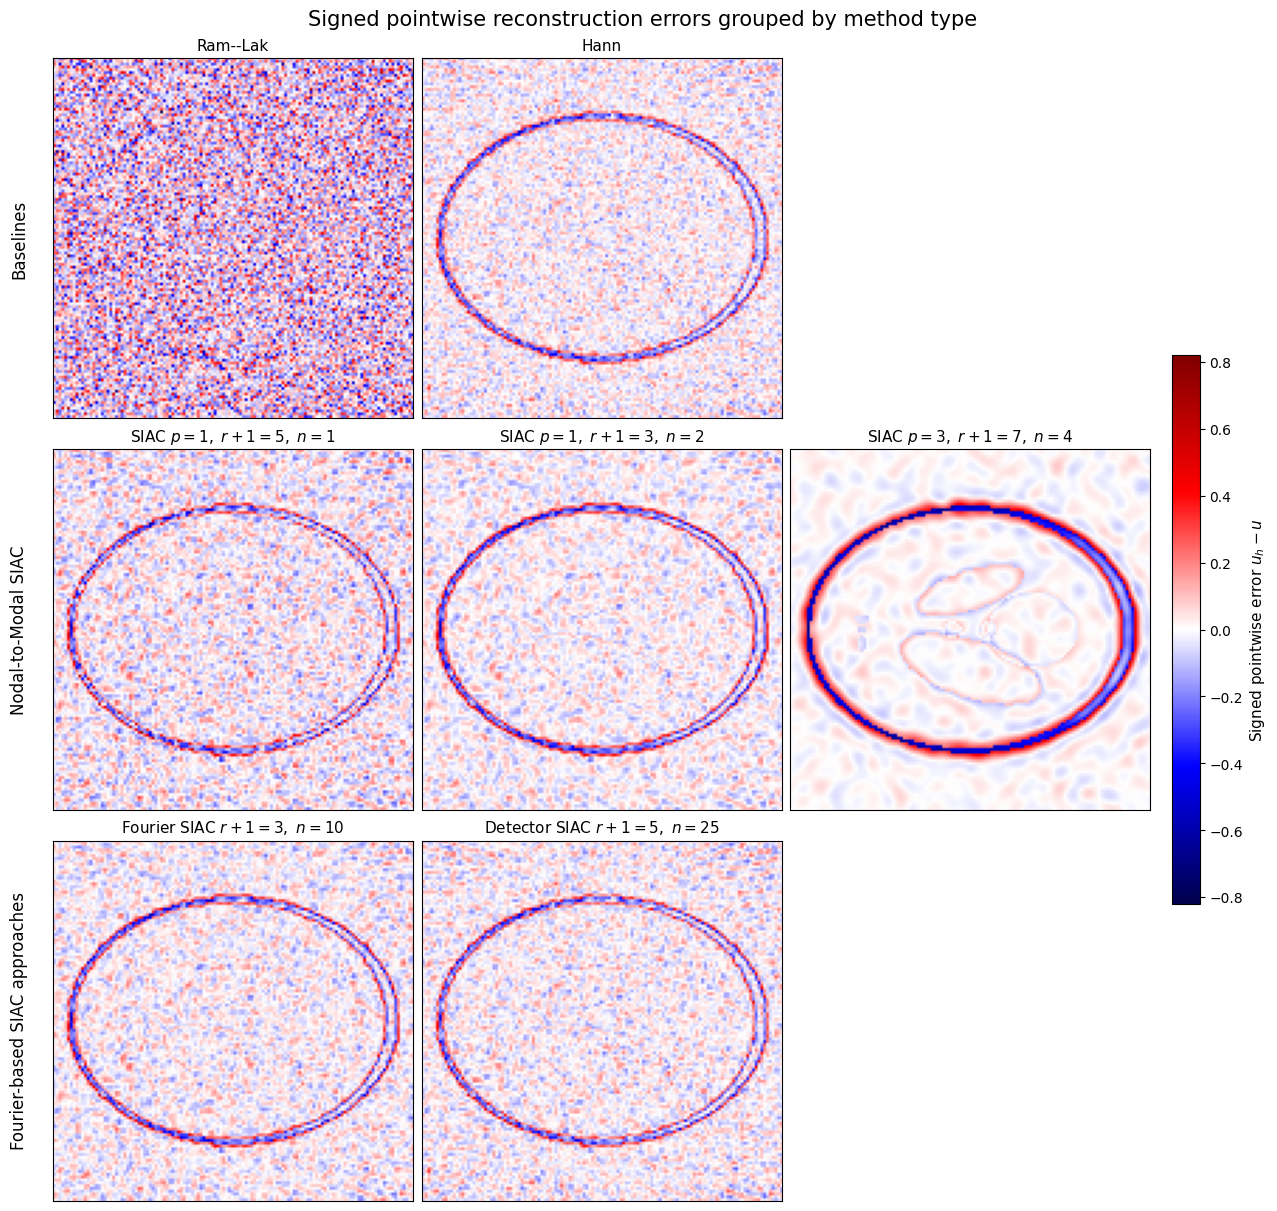

In [59]:
# ------------------------------------------------------------
# Large subplot: structured 2D signed pointwise errors
# Row 1: Baselines
# Row 2: Nodal-to-Modal SIAC
# Row 3: Fourier SIAC approaches
# ------------------------------------------------------------

# Select entries
baselines = [
    find_baseline(results, "Ram--Lak"),
    find_baseline(results, "Hann"),
]

nodal_modal = [
    find_siac(results, "Nodal-to-Modal SIAC", p=1, **{"r+1": 5}, n=1),
    find_siac(results, "Nodal-to-Modal SIAC", p=1, **{"r+1": 3}, n=2),
    find_siac(results, "Nodal-to-Modal SIAC", p=3, **{"r+1": 7}, n=4),
]

fourier_methods = [
    find_siac(results, "Fourier SIAC", **{"r+1": 3}, n=10),
    find_siac(results, "Detector SIAC", **{"r+1": 5}, n=25),
]

rows = [
    ("Baselines", baselines),
    ("Nodal-to-Modal SIAC", nodal_modal),
    ("Fourier-based SIAC approaches", fourier_methods),
]

nrows = len(rows)
ncols = max(len(row_items) for _, row_items in rows)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4.2 * ncols, 4.0 * nrows),
    constrained_layout=True
)

# Ensure axes is always 2D
axes = np.asarray(axes)
if axes.ndim == 1:
    axes = axes.reshape(nrows, ncols)

im = None

for row_idx, (row_title, row_items) in enumerate(rows):
    for col_idx in range(ncols):
        ax = axes[row_idx, col_idx]

        if col_idx < len(row_items):
            item = row_items[col_idx]

            im = ax.imshow(
                item["E"],
                cmap="seismic",
                vmin=vmin,
                vmax=vmax,
                extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
                origin="lower"
            )

            ax.set_title(item["label"], fontsize=11)
            ax.set_xticks([])
            ax.set_yticks([])

        else:
            ax.axis("off")

    # Add row label on the left side
    axes[row_idx, 0].set_ylabel(
        row_title,
        fontsize=12,
        rotation=90,
        labelpad=18
    )

# Shared colorbar
cbar = fig.colorbar(
    im,
    ax=axes.ravel().tolist(),
    fraction=0.025,
    pad=0.02
)
cbar.set_label(r"Signed pointwise error $u_h - u$", fontsize=11)

fig.suptitle(
    r"Signed pointwise reconstruction errors grouped by method type",
    fontsize=15
)

plt.show()

In [62]:
# ------------------------------------------------------------
# Select methods for slice comparisons
# ------------------------------------------------------------

ramlak = find_baseline(results, "Ram--Lak")
hann = find_baseline(results, "Hann")

# Main final-method comparison
nm_final = find_siac(
    results,
    "Nodal-to-Modal SIAC",
    p=1,
    **{"r+1": 5},
    n=1
)

fourier_final = find_siac(
    results,
    "Fourier SIAC",
    **{"r+1": 3},
    n=10
)

detector_final = find_siac(
    results,
    "Detector SIAC",
    **{"r+1": 5},
    n=25
)

# Classical DG-SIAC-inspired nodal-to-modal choices
nm_standard_p1 = find_siac(
    results,
    "Nodal-to-Modal SIAC",
    p=1,
    **{"r+1": 3},
    n=2
)

nm_standard_p3 = find_siac(
    results,
    "Nodal-to-Modal SIAC",
    p=3,
    **{"r+1": 7},
    n=4
)

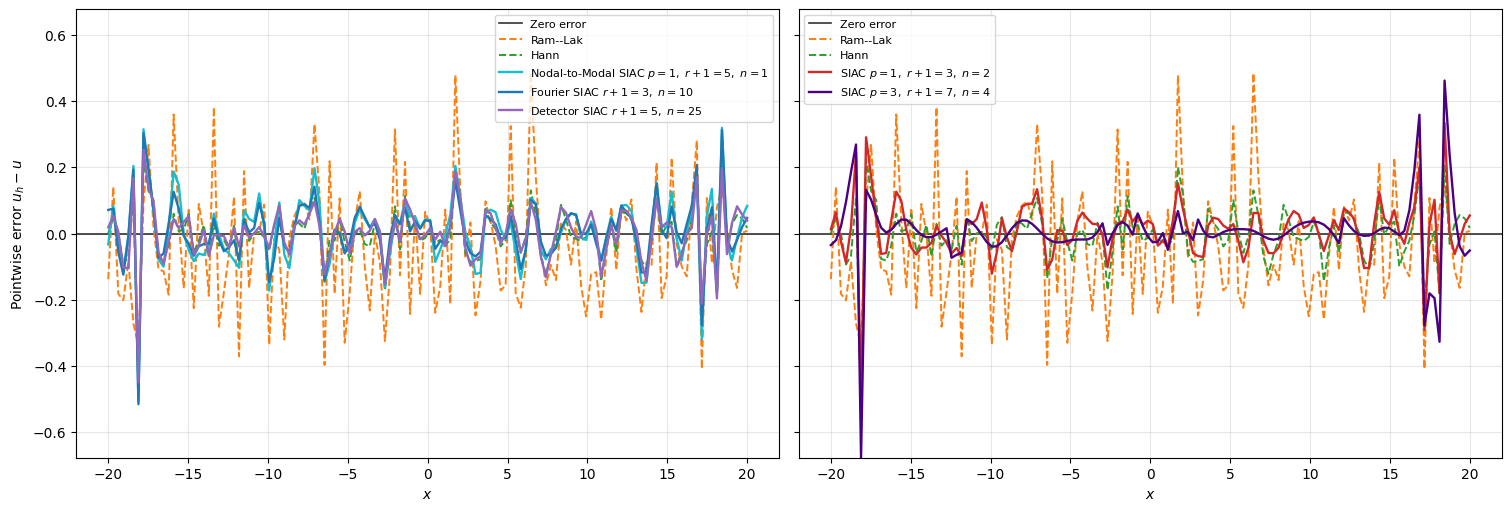

In [65]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Consistent color scheme
# ------------------------------------------------------------

COLORS = {
    "Ram--Lak": "tab:orange",
    "Hann": "tab:green",
    "NM_p1_r5_n1": "tab:cyan",     # p=1, r+1=5, n=1
    "NM_p1_r3_n2": "tab:red",      # p=1, r+1=3, n=2
    "NM_p3_r7_n4": "indigo",       # p=3, r+1=7, n=4
    "Fourier": "tab:blue",         # new
    "Detector": "tab:purple",      # new
    "Zero": "black",
}

save_path = Path("figures/shepp_logan_pointwise_error_slices.pdf")
save_path.parent.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1 x 2 subplot: central horizontal pointwise error slices
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
    sharey=True,
    constrained_layout=True
)

slice_errs = [
    ramlak["E"][slice_idx, :],
    hann["E"][slice_idx, :],
    nm_final["E"][slice_idx, :],
    fourier_final["E"][slice_idx, :],
    detector_final["E"][slice_idx, :],
    nm_standard_p1["E"][slice_idx, :],
    nm_standard_p3["E"][slice_idx, :],
]

slice_vmax = max(np.max(np.abs(e)) for e in slice_errs)
if slice_vmax == 0:
    slice_vmax = 1e-15

slice_vmin = -slice_vmax

# ------------------------------------------------------------
# Left: final selected methods
# ------------------------------------------------------------

ax = axes[0]

ax.axhline(
    0.0,
    color=COLORS["Zero"],
    linewidth=1.2,
    alpha=0.8,
    label="Zero error"
)

ax.plot(
    x,
    ramlak["E"][slice_idx, :],
    "--",
    linewidth=1.4,
    color=COLORS["Ram--Lak"],
    label="Ram--Lak"
)

ax.plot(
    x,
    hann["E"][slice_idx, :],
    "--",
    linewidth=1.4,
    color=COLORS["Hann"],
    label="Hann"
)

ax.plot(
    x,
    nm_final["E"][slice_idx, :],
    linewidth=1.7,
    color=COLORS["NM_p1_r5_n1"],
    label=r"Nodal-to-Modal SIAC $p=1,\ r+1=5,\ n=1$"
)

ax.plot(
    x,
    fourier_final["E"][slice_idx, :],
    linewidth=1.7,
    color=COLORS["Fourier"],
    label=r"Fourier SIAC $r+1=3,\ n=10$"
)

ax.plot(
    x,
    detector_final["E"][slice_idx, :],
    linewidth=1.7,
    color=COLORS["Detector"],
    label=r"Detector SIAC $r+1=5,\ n=25$"
)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"Pointwise error $u_h-u$")
ax.set_ylim(slice_vmin, slice_vmax)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc="best")

# ------------------------------------------------------------
# Right: classical DG-SIAC-inspired nodal-to-modal parameters
# ------------------------------------------------------------

ax = axes[1]

ax.axhline(
    0.0,
    color=COLORS["Zero"],
    linewidth=1.2,
    alpha=0.8,
    label="Zero error"
)

ax.plot(
    x,
    ramlak["E"][slice_idx, :],
    "--",
    linewidth=1.4,
    color=COLORS["Ram--Lak"],
    label="Ram--Lak"
)

ax.plot(
    x,
    hann["E"][slice_idx, :],
    "--",
    linewidth=1.4,
    color=COLORS["Hann"],
    label="Hann"
)

ax.plot(
    x,
    nm_standard_p1["E"][slice_idx, :],
    linewidth=1.7,
    color=COLORS["NM_p1_r3_n2"],
    label=r"SIAC $p=1,\ r+1=3,\ n=2$"
)

ax.plot(
    x,
    nm_standard_p3["E"][slice_idx, :],
    linewidth=1.7,
    color=COLORS["NM_p3_r7_n4"],
    label=r"SIAC $p=3,\ r+1=7,\ n=4$"
)

ax.set_xlabel(r"$x$")
ax.set_ylim(slice_vmin, slice_vmax)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc="best")

# ------------------------------------------------------------
# Save before showing
# ------------------------------------------------------------

fig.savefig(
    save_path,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()